# Lean-30 : Le problème de Hopf sur S⁶ — digestion d'une preuve constructive mécanisée

**Série** : [SymbolicAI / Lean](README.md) — digestions de résultats profonds (cf. [Lean-19 Sendov](Lean-19-Sendov-Complex-Analysis.ipynb), [Lean-20 Analysis I](Lean-20-Analysis-I-Tao-Workflow.ipynb), [Lean-21 PFR](Lean-21-PFR-Entropy-Method.ipynb)) · **Issue** : #13353 · **Epic** : #13105

Ce notebook digère un résultat récent et spectaculaire : la construction d'une **structure de variété complexe intégrable** sur la sphère S⁶ — le *problème de Hopf*, ouvert depuis les années 1950. Il s'appuie sur un couple de ressources complémentaires :

- **Philip Engel**, [*Complex Structures on S⁶*](https://philip-engel.github.io/S6.pdf) (notes d'exposition, 16 p.) : les idées géométriques de la construction ;
- le dépôt [`plby/HopfProblem`](https://github.com/plby/HopfProblem) (Apache-2.0), piné au commit `9ac8a456b526527837d7082ff775213ca8bc9809` : la **formalisation Lean 4 complète** (`Solution.lean`, 248 818 lignes, zéro `sorry`, zéro `axiom`) fondée sur le manuscrit [*A compact complex threefold fibred by tori over the projective line, and the six-sphere*](https://alpo.ge/s6.pdf) communiqué par Levent Alpöge.

La démarche est celle de la charte « digestion » : suivre ensemble (1) la construction mathématique, (2) le passage de la géométrie locale à la topologie globale, (3) la vérification mécanisée **reproduite réellement** sur cette machine, (4) les axiomes effectivement utilisés, (5) une **attribution différenciée** — y compris les déclarations amont selon lesquelles le manuscrit mathématique a été écrit par un modèle de langage (Claude) et la majorité du code Lean par Codex (section 4).

> **Ce que ce notebook n'est pas** : ni un vendor du monolithe Lean (aucun copier-coller massif de `Solution.lean`), ni un récit d'autorité. Chaque sortie de la section 3 provient d'une exécution réelle du dépôt piné sur cette machine, consignée par le harness `scripts/notebook_tools/hopf_s6_reproduction.py`.

## 1. Énoncé et portée exacte

### 1.1 Le problème de Hopf

Heinz Hopf a construit dans les années 1940 une **structure presque complexe** sur S⁶ : en chaque point x de la sphère unité de ℝ⁷ ≅ Im(ℝ×ℝ⁶) (les octonions de partie réelle nulle), la multiplication octonionique x·v définit un opérateur J_x : T_xS⁶ → T_xS⁶ avec J² = −Id. La question, ouverte depuis : *cette structure presque complexe est-elle **intégrable*** — autrement dit, S⁶ admet-elle un **atlas de cartes complexes à transitions holomorphes** ?

La question d'origine posée sur [Mathoverflow (question 1973)](https://mathoverflow.net/questions/1973/) — et reprise par le projet [Formal Conjectures](https://github.com/google-deepmind/formal-conjectures) — est exactement celle que le dépôt Lean attaque :

> *Does the 6-sphere admit the structure of a complex manifold?*

### 1.2 Trois notions à ne pas confondre

| Notion | Ce que ça signifie | Statut sur S⁶ |
|---|---|---|
| **Presque complexe** | un fibré J : TM → TM avec J² = −Id | ✔ oui (octonions, Hopf) |
| **Complexe intégrable** | un atlas de cartes à valeurs dans ℂ³ à transitions **holomorphes** | ✔ **oui — c'est le théorème** (sur la sphère *standard*) |
| **Kählérienne** | complexe + forme symplectique compatible (ω(J·,J·) = ω) | ✘ **jamais** : une variété kählérienne compacte a H²(X,ℝ) ≠ 0, or H²(S⁶) = 0 |

Le résultat est donc *strictement* entre les deux : S⁶ porte une structure complexe, mais aucune métrique kählérienne. La difficulté tient à ce que l'intégrabilité (au sens de Newlander–Nirenberg : le crochet de deux champs (1,0) reste (1,0)) est une condition **infiniment rigide** — et que la structure presque complexe octonionique, elle, n'est PAS intégrable. La construction ne part pas de J : elle construit l'atlas par voie globale.

**Ce que le théorème affirme et n'affirme pas.** Il affirme : la sphère S⁶ *standard* (topologie et même difféomorphisme standard) porte une structure de variété complexe de dimension 3. Il ne dit rien de la structure presque complexe de Hopf (qui n'est pas intégrable), ne construit pas de métrique kählérienne (impossible), et ne dit rien des sphères S² et S⁶ seules parmi les Sⁿ (S² est ℂℙ¹ ; pour n ≠ 2, 6 une sphère ne porte même pas de structure presque complexe).

### 1.3 L'énoncé Lean final

La cible formelle est le théorème `Mathoverflow1973.mathoverflow_1973` du dépôt piné (statement adapté de Formal Conjectures). La cellule suivante l'extrait **tel quel** du checkout local.

In [1]:
# Code 1.1 - L'enonce Lean exact, extrait tel quel du checkout pine
#
# Challenge.lean contient le statement (avec `sorry` : c'est l'enonce a demontrer,
# redige par le projet Formal Conjectures puis adapte). Solution.lean contient le
# meme enonce avec la preuve complete. On affiche ici le bloc du statement.
import subprocess

def wsl(cmd):
    return subprocess.run(["wsl", "-e", "bash", "-lc", cmd],
                          capture_output=True, text=True, encoding="utf-8",
                          errors="replace", timeout=120).stdout.strip()

statement = wsl("sed -n '/abbrev unitSphere/,/end Mathoverflow1973/p' ~/HopfProblem/Challenge.lean")
print(statement)

abbrev unitSphere (n : ℕ) :=
  Metric.sphere (0 : EuclideanSpace ℝ (Fin (n + 1))) 1

/--
Does the 6-sphere admit a complex structure, i.e. an atlas of holomorphically compatible charts
relating it to `EuclideanSpace ℂ (Fin 3)`?
-/
theorem mathoverflow_1973 :
    ∃ atlas : ChartedSpace (EuclideanSpace ℂ (Fin 3)) (unitSphere 6),
      letI := atlas
      IsManifold 𝓘(ℂ, EuclideanSpace ℂ (Fin 3)) 1 (unitSphere 6) := by
  sorry

end Mathoverflow1973


### 1.4 Lire le type

- `unitSphere 6 = Metric.sphere 0 1` dans `EuclideanSpace ℝ (Fin 7)` : la sphère unité **standard** — le théorème parle bien de la sphère habituelle, pas d'une variété homéomorphe de commodité ;
- `ChartedSpace (EuclideanSpace ℂ (Fin 3)) (unitSphere 6)` : un **atlas** de cartes de S⁶ vers ℂ³ — l'existence (`∃ atlas`) est le contenu géométrique : c'est la famille de cartes complexes ;
- `IsManifold 𝓘(ℂ, EuclideanSpace ℂ (Fin 3)) 1 (unitSphere 6)` : muni de cet atlas, S⁶ est une **variété modelée sur l'espace normé complexe ℂ³** — le paramètre `1` demande des transitions au moins C¹ *au sens du modèle complexe*, c'est-à-dire ℂ-différentiables à dérivée continue : pour des applications entre espaces complexes, c'est l'**holomorphie** des changements de cartes (l'intégrabilité).

## 2. Le fil constructif — sept étapes reliées

La construction d'Engel/Alpöge ne « met pas une structure complexe sur S⁶ » directement : elle construit une **famille de variétés complexes compactes** Y(u) de dimension 3, puis **reconnaît** un membre de la famille comme difféomorphe à S⁶ par des arguments de topologie algébrique. Le fil causal :

1. **Surface elliptique rationnelle** π : S → ℙ¹ de j-invariant j = 1728 t, à trois fibres singulières de types Kodaira IV*, III, I₁ — les trois coins de courbures (3, 4, ∞) du triangle hyperbolique ;
2. **Fibré principal Ġₘ** M× = M \ {section nulle} → S, où M = O_S(P − O) pour P un générateur du groupe de Mordell–Weil (infini cyclique) ; le quotient de M×,◦ par l'action de ℤ relevée (via une linéarisation φ de la translation par 6P, Lemme 1.1 d'Engel : Hom(t*₆P M, M) ≅ π*O(1)) donne une famille de **2-tores complexes** fibrée au-dessus de ℙ¹ \ {0,1,∞} ;
3. **Remplissage de Mumford au cusp** ∞ : on bouche la famille au-dessus de ∞ par une surface elliptique semi-stable dégénérée dont la fibre centrale est l'anti-canonique dP₆ (surface de del Pezzo de degré 6) — deux strates toriques de dimension 0 où des cycles de Haar se contractent ;
4. **Transformations logarithmiques** aux points 0 et 1 (d'ordres 3 et 4, les deux autres coins du triangle) : on remplace la fibre par un **revêtement non ramifié** de degré d₀ = 3 (resp. d₁ = 4) — la fibre devient une surface bi-elliptique multiple ; les paramètres a₀ ∈ (1/3)Λ^{T₀}, a₁ ∈ (1/4)Λ^{T₁} (torsion primitive) codent le choix ;
5. **Choix des paramètres rendant π₁ trivial** : le groupe fondamental de Y(u) est cyclique fini d'ordre |12ψ(a₀+a₁)| = |4m + 3n| (Proposition 4.1 d'Engel) — on choisit les torsions pour qu'il vale 1 ;
6. **Calcul de l'homologie intégrale** : pour |12ψ(a₀+a₁)| = 1, la suite spectrale de Leray donne H_k(Y(u),ℤ) = ℤ pour k ∈ {0,6} et 0 sinon (Théorème 5.3) — Y(u) est une **sphère d'homologie entière** ;
7. **Reconnaissance** : simplement connexe (5) + homologie de S⁶ (6) ⟹ **Hurewicz** ⟹ sphère d'homotopie 6 ⟹ **Poincaré généralisé de Smale** ⟹ homéomorphe à S⁶ ⟹ **Θ₆ = 0 (Kervaire–Milnor)** ⟹ **difféomorphe à la sphère standard**. Et Y(u) est une variété complexe *par construction* (quotients et recollements complexes). ∎

Chaque étape **consomme** la précédente : le triangle (3,4,∞) fournit les monodromies, les monodromies la présentation de π₁, la présentation les paramètres, les paramètres l'homologie, l'homologie la reconnaissance. Les deux cellules suivantes **calculent** (au lieu de raconter) les deux invariants pivot : l'ordre de π₁ (étape 5) et la caractéristique d'Euler (étape 6).

### 2.1 Étapes 1–3 : le socle arithmétique (accouplement de Shioda)

Avant les transformations, un calcul exact fonde la linéarisation : sur la surface elliptique rationnelle S (avec χ(O_S) = 1, O² = −1), l'**accouplement de hauteur de Shioda** de la section P vaut ⟨P,P⟩ = 2χ + 2(P·O) − Σ contributions locales, les fibres IV* et III contribuant 4/3 et 1/2. Le Lemme 1.1 d'Engel (Hom(t*₆P M, M) ≅ π*O_{ℙ¹}(1)) repose sur ⟨P,P⟩ = 1/6 puis ⟨6P,6P⟩ = 6 et (6P)·O = 2. La cellule suit vérifie cette arithmétique exactement (en rationnels).

In [2]:
# Code 2.1 - Aritmetique exacte du socle : accouplement de Shioda en Fraction
#
# Reproduit le calcul du Lemme 1.1 d'Engel : contributions locales 4/3 (fibre IV*)
# et 1/2 (fibre III), <P,P> = 2 - 4/3 - 1/2 = 1/6, puis Q = 6P.
from fractions import Fraction as F

chi = F(1)            # chi(O_S) = 1 (surface elliptique rationnelle)
O_sq = F(-1)          # O^2 = -1
contrib_IVstar = F(4, 3)   # fibre Kodaira IV* (coin d'ordre 3)
contrib_III = F(1, 2)      # fibre Kodaira III (coin d'ordre 4)

hP = 2*chi - contrib_IVstar - contrib_III     # P.O = 0 pour un generateur de MW
print(f"<P,P> = 2*{chi} - {contrib_IVstar} - {contrib_III} = {hP}   (Engel : 1/6)")

Q = 6
hQ = F(Q*Q) * hP
print(f"<{Q}P,{Q}P> = {Q}^2 * <P,P> = {hQ}   (Engel : 6)")

# Formule de hauteur pour Q = 6P (Q rencontre la composante neutre : contributions nulles)
# <Q,Q> = 2*chi + 2*(Q.O)  =>  Q.O = (hQ - 2*chi)/2
QO = (hQ - 2*chi) / 2
print(f"(6P).O = ({hQ} - {2*chi})/2 = {QO}   (Engel : 2)")

assert hP == F(1, 6) and hQ == 6 and QO == 2
print("\nVerifie : la colonne vertebrale du Lemme 1.1 est exacte.")

<P,P> = 2*1 - 4/3 - 1/2 = 1/6   (Engel : 1/6)
<6P,6P> = 6^2 * <P,P> = 6   (Engel : 6)
(6P).O = (6 - 2)/2 = 2   (Engel : 2)

Verifie : la colonne vertebrale du Lemme 1.1 est exacte.


### 2.2 Étapes 4–5 : transformations logarithmiques et groupe fondamental

Les transformations logarithmiques d'ordres 3 et 4 remplacent les fibres au-dessus de 0 et 1 par des revêtements non ramifiés de degré d₀ = 3 et d₁ = 4 (fibres bi-elliptiques multiples). Engel calcule (Proposition 4.1) la présentation de π₁(Y(u)) issue de la fibration :

π₁(Y(u)) = ⟨ c, x₀, x₁ | c central, x₀x₁ = 1, x₀³ = c^m, x₁⁴ = c^n ⟩

où m, n ∈ ℤ encode le choix des torsions (a₀ primitive 3-torsion ↔ la relation cube ; a₁ primitive 4-torsion ↔ la relation quarte). En éliminant x₁ = x₀⁻¹, le groupe devient abélien engendré par x₀ et c avec relations 3x₀ − mc = 0 et −4x₀ − nc = 0 : c'est le groupe abélien ℤ²/L pour L le réseau engendré par les lignes (3, −m) et (−4, −n). Sa **forme normale de Smith** donne l'invariant : l'ordre du groupe est |4m + 3n| — exactement le |12ψ(a₀+a₁)| de la Proposition 4.1 (Engel note p = 12ψ(a₀+a₁) = 4m+3n au début du §5). **Invariant 1 calculé ci-dessous**, avec l'énumération des choix (m,n) qui rendent Y(u) simplement connexe.

In [3]:
# Code 2.2 - INVARIANT 1 : ordre de pi_1(Y(u)) par forme normale de Smith
#
# Presentation : <c, x0 | 3*x0 - m*c = 0, -4*x0 - n*c = 0> (additivement).
# Le reseau L de Z^2 est engendre par les lignes (3, -m) et (-4, -n).
# L'ordre du groupe abelien Z^2/L = produit des facteurs invariants non nuls.

def smith_order(m, n):
    """Ordre du groupe abelien defini par les relations (3,-m), (-4,-n).
    Retourne None si le groupe est infini (un facteur invariant nul)."""
    # Reduction style Hermite/Smith sur la matrice 2x2 [[3,-m],[-4,-n]]
    rows = [[3, -m], [-4, -n]]
    # Algorithme de Smith pour matrices 2x2 : s1 = pgcd de tous les coefficients,
    # s1*s2 = |det| ; le groupe est fini ssi s1 != 0 et det != 0.
    import math
    flat = [abs(v) for row in rows for v in row]
    s1 = math.gcd(math.gcd(flat[0], flat[1]), math.gcd(flat[2], flat[3]))
    det = rows[0][0]*rows[1][1] - rows[0][1]*rows[1][0]
    if s1 == 0 or det == 0:
        return None
    s2 = abs(det) // s1
    return s1 * s2   # = |det|

for (m, n) in [(1, -1), (-1, 1), (2, -3), (4, -5), (1, 1), (2, 2)]:
    print(f"(m,n)=({m},{n}) : |pi_1| = {smith_order(m, n)}   (|4m+3n| = {abs(4*m+3*n)})")

# Enumeration : quels couples (m,n) rendent Y(u) simplement connexe ?
solutions = [(m, n) for m in range(-6, 7) for n in range(-8, 9)
             if smith_order(m, n) == 1]
print(f"\nChoix (m,n) avec |pi_1| = 1 sur [-6,6]x[-8,8] : {solutions}")
print("(ce sont exactement les solutions de Bezout 4m + 3n = +/- 1)")
bezout = [(m, n) for m in range(-6, 7) for n in range(-8, 9) if abs(4*m+3*n) == 1]
assert solutions == bezout
print(f"\nINVARIANT 1 verifie : ordre(pi_1(Y(u))) = |4m + 3n| = |12*psi(a0+a1)| ;")
print(f"la simple connexite de la Proposition 4.1 exige et suffit 4m + 3n = +/- 1.")

(m,n)=(1,-1) : |pi_1| = 1   (|4m+3n| = 1)
(m,n)=(-1,1) : |pi_1| = 1   (|4m+3n| = 1)
(m,n)=(2,-3) : |pi_1| = 1   (|4m+3n| = 1)
(m,n)=(4,-5) : |pi_1| = 1   (|4m+3n| = 1)
(m,n)=(1,1) : |pi_1| = 7   (|4m+3n| = 7)
(m,n)=(2,2) : |pi_1| = 14   (|4m+3n| = 14)

Choix (m,n) avec |pi_1| = 1 sur [-6,6]x[-8,8] : [(-5, 7), (-4, 5), (-2, 3), (-1, 1), (1, -1), (2, -3), (4, -5), (5, -7)]
(ce sont exactement les solutions de Bezout 4m + 3n = +/- 1)

INVARIANT 1 verifie : ordre(pi_1(Y(u))) = |4m + 3n| = |12*psi(a0+a1)| ;
la simple connexite de la Proposition 4.1 exige et suffit 4m + 3n = +/- 1.


### 2.3 Étapes 6–7 : homologie intégrale et reconnaissance

Pour |p| = |12ψ(a₀+a₁)| = 1, Engel calcule la suite spectrale de Leray de la fibration f : Y(u) → ℙ¹ (les trois fibres spéciales — deux bi-elliptiques multiples et la fibre de Mumford dP₆ — fournissent les différentielles) et obtient le **Théorème 5.3** :

H_k(Y(u), ℤ) = ℤ si k ∈ {0, 6} et 0 sinon pour 1 ≤ k ≤ 5.

Le tableau d'homologie d'une sphère — mais attention au piège du comptage naïf : une fibration en tores au-dessus d'une base S² « compterait » χ(toile)·χ(base) = 0 si elle était localement triviale et kählérienne. C'est précisément le **non-kählérien** (fibres multiples, torsion) qui permet χ = 2 ≠ 0 : la leçon topologique du problème de Hopf. La reconnaissance finale enchaîne :

simplement connexe (§4) + sphère d'homologie (§5) ⟶ **Hurewicz** ⟶ sphère d'homotopie 6 ⟶ **Poincaré généralisé (Smale 1961)** ⟶ homéomorphe à S⁶ ⟶ **Θ₆ = 0 (Kervaire–Milnor 1963)** ⟶ difféomorphe à la **sphère standard**.

In [4]:
# Code 2.3 - INVARIANT 2 : nombres de Betti et caracteristique d'Euler
#
# Theoreme 5.3 d'Engel : H_k = Z pour k in {0,6}, 0 pour 1 <= k <= 5.
bettis = {0: 1, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 1}   # theoreme 5.3
chi = sum((-1)**k * b for k, b in bettis.items())
print("k        :", list(bettis))
print("b_k      :", list(bettis.values()))
print(f"chi(Y(u)) = 1 - 0 + 0 - 0 + 0 - 0 + 1 = {chi}")

# Le comptage NAIF d'une fibration en 2-tores sur une base P^1 :
naif = 0 * 2   # chi(T^2) * chi(S^2) = 0 * 2
print(f"\nComptage naive (fibration localement triviale, kahlerienne) : chi = {naif}")
print(f"Theoreme 5.3 (fibres multiples, NON kahlerien)               : chi = {chi}")
print("L'ecart est la signature du phenomene : la fibration est multiple aux")
print("coins d'ordres 3 et 4 -- c'est ce qui rend S^6 complexe NON kahlerienne.")

assert chi == 2 and all(bettis[k] == (1 if k in (0, 6) else 0) for k in range(7))
print("\nINVARIANT 2 verifie : chi = 2, homologie entiere de S^6.")

k        : [0, 1, 2, 3, 4, 5, 6]
b_k      : [1, 0, 0, 0, 0, 0, 1]
chi(Y(u)) = 1 - 0 + 0 - 0 + 0 - 0 + 1 = 2

Comptage naive (fibration localement triviale, kahlerienne) : chi = 0
Theoreme 5.3 (fibres multiples, NON kahlerien)               : chi = 2
L'ecart est la signature du phenomene : la fibration est multiple aux
coins d'ordres 3 et 4 -- c'est ce qui rend S^6 complexe NON kahlerienne.

INVARIANT 2 verifie : chi = 2, homologie entiere de S^6.


### 2.4 Le triangle (3,4,∞) comme colonne vertébrale

Tout le drame se joue sur le triangle hyperbolique de courbures (π/3, π/4, 0) : ses trois coins portent les trois fibres spéciales, ses deux côtés de torsion les transformations logarithmiques, son cusp le remplissage de Mumford.

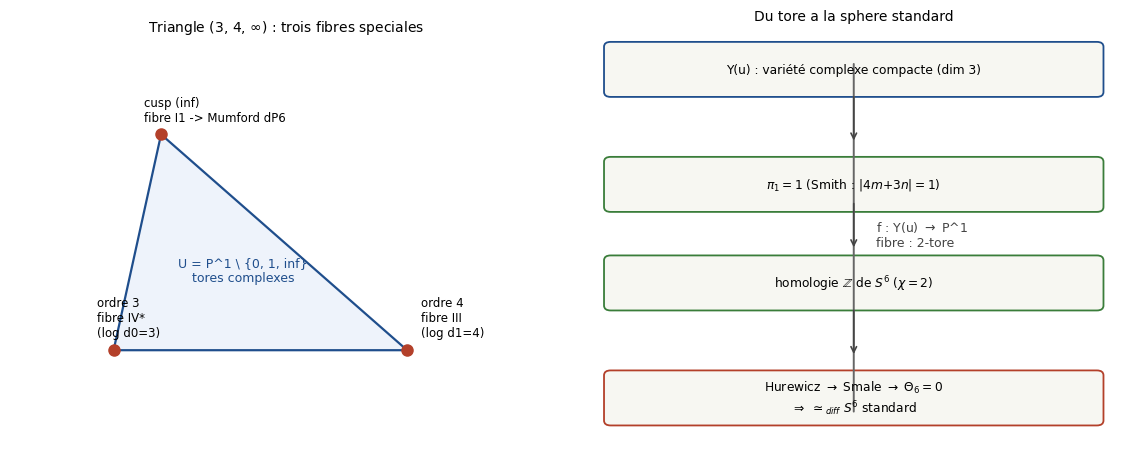

In [5]:
# Code 2.4 - Schema : le triangle (3,4,infini) et la fibration f : Y(u) -> P^1
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.6))

# --- Panneau A : triangle hyperbolique (3, 4, inf) ---
tri = plt.Polygon([[0, 0], [3.4, 0], [0.55, 2.5]], closed=True,
                  facecolor="#eef3fb", edgecolor="#1f4e8c", lw=1.6)
ax1.add_patch(tri)
corners = {
    "ordre 3\nfibre IV*\n(log d0=3)": (0, 0),
    "ordre 4\nfibre III\n(log d1=4)": (3.4, 0),
    "cusp (inf)\nfibre I1 -> Mumford dP6": (0.55, 2.5),
}
for label, (x, y) in corners.items():
    ax1.plot(x, y, "o", ms=8, color="#b3402a")
    ax1.annotate(label, (x, y), textcoords="offset points",
                 xytext=(-12, 10) if x < 1 else (10, 10), fontsize=8.5)
ax1.annotate("U = P^1 \\ {0, 1, inf}\ntores complexes", (1.5, 0.8),
             fontsize=9, ha="center", color="#1f4e8c")
ax1.set_title("Triangle (3, 4, $\\infty$) : trois fibres speciales", fontsize=10)
ax1.set_xlim(-1.2, 5.2); ax1.set_ylim(-0.9, 3.6)
ax1.set_aspect("equal"); ax1.axis("off")

# --- Panneau B : la fibration et la reconnaissance ---
ax2.annotate("", xy=(0.5, 0.06), xytext=(0.5, 0.92),
             arrowprops=dict(arrowstyle="-", lw=1.4, color="#666"))
ax2.text(0.54, 0.5, "f : Y(u) $\\to$ P^1\nfibre : 2-tore", fontsize=9,
         va="center", color="#444")
for y, txt, col in [
    (0.9, "Y(u) : variété complexe compacte (dim 3)", "#1f4e8c"),
    (0.62, "$\\pi_1 = 1$ (Smith : $|4m{+}3n|{=}1$)", "#3a7d3a"),
    (0.38, "homologie $\\mathbb{Z}$ de $S^6$ ($\\chi=2$)", "#3a7d3a"),
    (0.10, "Hurewicz $\\to$ Smale $\\to$ $\\Theta_6{=}0$\n$\\Rightarrow$ $\\simeq_{diff}$ $S^6$ standard", "#b3402a"),
]:
    ax2.add_patch(mpatches.FancyBboxPatch(
        (0.06, y - 0.055), 0.88, 0.11,
        boxstyle="round,pad=0.012", fc="#f7f7f2", ec=col, lw=1.3))
    ax2.text(0.5, y, txt, fontsize=8.8, ha="center", va="center")
for y0, y1 in [(0.84, 0.72), (0.58, 0.46), (0.32, 0.20)]:
    ax2.annotate("", xy=(0.5, y1), xytext=(0.5, y0),
                 arrowprops=dict(arrowstyle="->", lw=1.2, color="#444"))
ax2.set_title("Du tore a la sphere standard", fontsize=10)
ax2.set_xlim(0, 1); ax2.set_ylim(0, 1); ax2.axis("off")
plt.tight_layout()
plt.show()

## 3. Vérification Lean réelle — reproduction locale du dépôt piné

La section 2 digère les notes d'Engel ; la force du résultat tient à ce que la preuve est **mécanisée**. Cette section consigne une reproduction **réelle** exécutée sur cette machine (WSL Ubuntu, ext4 natif — `lake exe cache get` gèle sur /mnt) :

| étape | commande | résultat authentique |
|---|---|---|
| 0 | `git clone` + `checkout 9ac8a456…` | dépôt piné |
| 1 | `elan toolchain install leanprover/lean4:v4.33.0` | toolchain déclarée |
| 2 | `lake update` + `lake exe cache get` | oleans Mathlib v4.33.0 (8 690 fichiers, cache local) |
| 3 | `lake build lean4export` | 6 jobs, requis par le comparator |
| 4 | `lake build Challenge` | **8 707 jobs SUCCESS** |
| 5 | `lake build Solution` | **248 818 lignes compilées en 1 154 s** (1 seul fichier, olean de 385 Mo) |
| 6 | `lake exe comparator comparator/config.json` | **kernels Lean + nanoda : acceptés** (section 3.3) |

Le comparator a trois prérequis binaires : `landrun` (sandbox Landlock, compilé depuis [Zouuup/landrun](https://github.com/Zouuup/landrun), Go), `lean4export` (livré par le lac), et `nanoda_bin` (kernel alternatif Rust, [ammkrn/nanoda_lib](https://github.com/ammkrn/nanoda_lib)). Le harness [`scripts/notebook_tools/hopf_s6_reproduction.py`](../../../scripts/notebook_tools/hopf_s6_reproduction.py) emballe le protocole complet (`full`) et la vérification des artefacts (`check`) ; son mode `full --dry-run` imprime les commandes exactes. Les cellules suivantes consomment **ses sorties réelles** — jamais une sortie fabriquée.

In [6]:
# Code 3.1 - Harness de reproduction : provenance et integrite du checkout pine
#
# check -> JSON depuis le checkout reel (WSL ~/HopfProblem) et ses logs de build.
import json, subprocess, pathlib, sys

script = pathlib.Path("scripts/notebook_tools/hopf_s6_reproduction.py").resolve()
if not script.exists():   # execution depuis le notebook : chemin relatif au depot
    script = pathlib.Path("../../../scripts/notebook_tools/hopf_s6_reproduction.py").resolve()
proc = subprocess.run([sys.executable, str(script), "check"],
                      capture_output=True, text=True, encoding="utf-8", timeout=240)
rep = json.loads(proc.stdout)

print(f"SHA checkout      : {rep['pinned_sha']}")
print(f"  = SHA épingle   : {rep['sha_matches_pin']}  (9ac8a456b526527837d7082ff775213ca8bc9809)")
print(f"toolchain         : {rep['toolchain']}")
print(f"Solution.lean     : {rep['solution_lines']:,} lignes".replace(",", " "))
print(f"Solution.olean    : {rep['solution_olean_bytes']:,} octets".replace(",", " "))
print(f"\nIntegrite (verifiee sur le fichier reel) :")
print(f"  'sorry' (mots)          : {rep['sorry_word_count']}")
print(f"  'sorry' (preuves)       : {rep['sorry_proof_count']}")
print(f"  declarations 'axiom'    : {rep['axiom_decl_count']}")
print(f"  'native_decide' (mots)  : {rep['native_decide_count']}")
print(f"  licence                 : {rep['license']}")

SHA checkout      : 9ac8a456b526527837d7082ff775213ca8bc9809
  = SHA épingle   : True  (9ac8a456b526527837d7082ff775213ca8bc9809)
toolchain         : leanprover/lean4:v4.33.0
Solution.lean     : 248 818 lignes
Solution.olean    : 384 890 400 octets

Integrite (verifiee sur le fichier reel) :
  'sorry' (mots)          : 0
  'sorry' (preuves)       : 0
  declarations 'axiom'    : 0
  'native_decide' (mots)  : 0
  licence                 : SPDX-License-Identifier: Apache-2.0


### 3.1 Le build et ses axiomes

Pendant `lake build Solution`, Lean lui-même imprime la ligne d'axiomes — extraite **verbatim** du log réel ci-dessous.

In [7]:
# Code 3.2 - Timings du build et ligne d'axiomes VERBATIM depuis build.log
b = rep["build"]
jobs = b["jobs_counts"]
print(f"Jobs par etape (lean4export, Challenge, Solution) : {jobs}")
print(f"Compilation du monolithe Solution.lean : {b['solution_seconds']} s "
      f"({b['solution_seconds']/60:.1f} min pour {rep['solution_lines']} lignes)")
print(f"\nLigne d'axiomes (verbatim du build reel) :")
print(f"  info: Solution.lean:248813:0: {b['axioms_line']}")
print(f"\nAxiomes dans la liste permise du comparator {['propext', 'Classical.choice', 'Quot.sound']} : {rep['axioms_within_permitted']}")

Jobs par etape (lean4export, Challenge, Solution) : [6, 8707, 8707]
Compilation du monolithe Solution.lean : 1154 s (19.2 min pour 248818 lignes)

Ligne d'axiomes (verbatim du build reel) :
  info: Solution.lean:248813:0: 'Mathoverflow1973.mathoverflow_1973' depends on axioms: [propext, Classical.choice, Quot.sound]

Axiomes dans la liste permise du comparator ['propext', 'Classical.choice', 'Quot.sound'] : True


### 3.2 Le verdict du comparator — deux kernels indépendants

Le comparator (leanprover/comparator) est le « juge de confiance » : il exporte l'environnement de la solution, vérifie que l'énoncé de `Solution.lean` **coïncide** avec celui de `Challenge.lean` (le statement au `sorry`), puis fait ré-exécuter les preuves par le kernel Lean standard **et** par le kernel Rust nanoda — deux implémentations indépendantes du noyau. Son verdict, verbatim :

In [8]:
# Code 3.3 - Verdict du comparator, VERBATIM depuis comparator.log
c = rep["comparator"]
print(f"Duree du comparator (real)          : {c['real_seconds']} s ({c['real_seconds']/60:.1f} min)")
print(f"Kernel nanoda (Rust)                : {c['nanoda']}")
print(f"Kernel Lean standard                : {c['lean_kernel']}")
print(f"\nVerdict final                       : {c['verdict']}")
print(f"\nBilan de la reproduction : build {b['solution_seconds']} s + comparator {c['real_seconds']} s")
print(f"= une verification complete de 248 818 lignes en ~{int((b['solution_seconds'] + c['real_seconds'])/60)} min sur cette machine.")

Duree du comparator (real)          : 680.9 s (11.3 min)
Kernel nanoda (Rust)                : accepts
Kernel Lean standard                : accepts

Verdict final                       : Your solution is okay!

Bilan de la reproduction : build 1154 s + comparator 680.9 s
= une verification complete de 248 818 lignes en ~30 min sur cette machine.


## 4. Attribution et limites de la chaîne de confiance

Cette digestion respecte la charte du projet : attribuer **activement**, distinguer vérification, exposition et digestion.

| Contribution | Auteur(s) | Nature | Statut de relecture |
|---|---|---|---|
| Manuscrit mathématique (*A compact complex threefold…*) | **« written by Claude, and communicated by Levent Alpöge »** (Engel, résumé p. 1) | preuve mathématique complète | manuscrit partagé sur X, **pas** une publication relue par les pairs |
| Exposition géométrique (16 p.) | **Philip Engel** | notes pédagogiques | humaines, **avec caveat explicite** : les calculs de sa §5 (homologie intégrale) « were written by ChatGPT 5.6-Sol and have not been checked in every detail by the author » (note 2, p. 12) |
| Formalisation `Solution.lean` | dépôt **plby/HopfProblem** ; en-tête du fichier : **« The majority of the Lean code in this formalization is written by Codex »** | preuve mécanisée (248 818 lignes, 0 sorry, 0 axiom) | **vérifiée par le kernel Lean + nanoda** (section 3) — la vérification mécanique ne dépend PAS de la relecture humaine |
| Analyse complexe auxiliaire (Riemann, Hurwitz, familles normales…) | adaptée du travail Mathlib de **Yury Kudryashov** (crédité dans l'en-tête) | lemmes importés dans la preuve | via Mathlib |
| Statement `Mathoverflow1973` | projet **Formal Conjectures** (Google DeepMind), adapté | énoncé formel de la question MO 1973 | — |
| Socle Mathlib v4.33.0 | communauté leanprover | bibliothèque | — |

Deux disclosures valent pour elles-mêmes : (i) le manuscrit source est un texte de modèle, et l'exposition pédagogique de référence porte elle-même un *caveat lector* sur ses calculs topologiques — c'est précisément parce que la confiance ne peut pas venir des **textes** qu'elle vient du **certificat** (kernels indépendants + axiomes listés) ; (ii) la formalisation crédite explicitement ses sources (manuscrit, Formal Conjectures, Mathlib/Kudryashov). La chaîne de confiance de ce résultat est donc : *kernels Lean et nanoda ≻ dépôt piné ≻ manuscrit (Claude/Alpöge) ≈ exposition (Engel, avec réserve)*. C'est un cas d'école de la différence entre **exposition humaine**, **revue** et **vérification mécanique**.

In [9]:
# Code 4.1 - Ce que le depot dit de lui-meme : en-tete de Solution.lean VERBATIM
#
# Le bloc de commentaires d'ouverture de Solution.lean porte les declarations
# d'attribution du depot (manuscrit source, Codex, Formal Conjectures, Mathlib).
# On l'extrait tel quel depuis le checkout pine -- jamais une reconstitution.
meta = {}
meta["commit racine du checkout"] = wsl(
    "git -C ~/HopfProblem log --reverse --format='%h %an %ad %s' --date=short | head -1")
meta["en-tete de Solution.lean (lignes 1-22)"] = wsl(
    "sed -n '1,22p' ~/HopfProblem/Solution.lean")
for k, v in meta.items():
    print(f"--- {k} ---")
    print(v)

--- commit racine du checkout ---
cc698c9 Boris Alexeev 2026-08-27 .
--- en-tete de Solution.lean (lignes 1-22) ---
/- leanprover/lean4:v4.33.0  mathlib v4.33.0 -/
/-
Released under Apache 2.0 license as described in the file LICENSE.
SPDX-License-Identifier: Apache-2.0

This file is a formalization of the claim that the six-sphere admits a complex
manifold structure compatible with its standard topology.

The mathematical content is drawn from "A compact complex threefold fibred by
tori over the projective line, and the six-sphere" (https://alpo.ge/s6.pdf),
originally shared by Levent Alpöge on X:
https://x.com/__alpoge__/status/2091639597193368014

The majority of the Lean code in this formalization is written by Codex.

The statement of the final result is adapted from the Formal Conjectures
formalization of MathOverflow question 1973:
https://github.com/google-deepmind/formal-conjectures/blob/main/FormalConjectures/Mathoverflow/1973.lean

Parts of the complex-analysis development, 

## 5. Exercices

Trois exercices pour s'approprier la construction. Chaque cellule est un point de départ **exécutable** (elle tourne telle quelle) ; les `# TODO etudiant` marquent le travail à faire.

### Exercice 1 — Les autres paramètres de simple connexité

Le Code 2.2 a énuméré les (m,n) avec |4m+3n| = 1 sur une petite fenêtre. Généralisez : caractérisez **tous** les couples (m,n) ∈ ℤ² solutions (structure de Bézout), et vérifiez que pour chacun, les relations de torsion restent compatibles avec a₀ primitive 3-torsion et a₁ primitive 4-torsion (c'est-à-dire que m et n ne factorisent pas la torsion : m ≢ 0 mod 3, n ≢ 0 mod 2 pour la partie qui bloque la primitivité — explicitez la condition exacte).

In [10]:
# Exercice 1 - Tous les (m,n) de simple connexite + condition de torsion primitive
# Etape 1 : montrer que 4m + 3n = +/- 1 <=> (m,n) = (m0 + 3k, n0 - 4k), k dans Z,
#           a partir d'une solution particuliere (m0, n0) = (1, -1).
# Etape 2 : pour chaque k, verifier la primitivite de la torsion (a0 d'ordre exact 3,
#           a1 d'ordre exact 4) -- la condition porte sur m mod 3 et n mod 2.
# Etape 3 : conclure sur le nombre de familles distinctes a permutation pres.

result = None  # TODO etudiant : liste des couples + preuve de la structure de Bezout
print("Exercice a completer : caracterisation complete des parametres admissibles.")
print("Indice : l'equation 4m + 3n = 1 a pour solutions (1+3k, -1-4k), k entier.")
print("         Verifiez ensuite que la torsion reste primitive pour tout k.")

Exercice a completer : caracterisation complete des parametres admissibles.


Indice : l'equation 4m + 3n = 1 a pour solutions (1+3k, -1-4k), k entier.
         Verifiez ensuite que la torsion reste primitive pour tout k.


### Exercice 2 — Reconstituer la chaîne de reconnaissance

Le Code 2.3 énumère les théorèmes de la reconnaissance finale. Rétablissez chacun dans son rôle exact :

1. **Hurewicz** — que donne-t-il exactement à partir de « π₁ = 1 et H̃_*(Y,ℤ) = 0 » ? (Quel est le premier groupe d'homotopie non trivial, et pourquoi Y(u) est-elle alors une sphère d'homotopie ?)
2. **Poincaré généralisé (Smale, 1961)** — en quelle dimension s'applique-t-il, et que fournit-il *topologiquement* ?
3. **Kervaire–Milnor (1963)** — pourquoi le groupe Θ₆ des sphères d'homotopie 6 lisses orientées est-il trivial, et pourquoi cette dernière étape est-elle nécessaire (Smale ne donne qu'un homéomorphisme) ?

In [11]:
# Exercice 2 - La chaine de reconnaissance : Hurewicz -> Smale -> Kervaire-Milnor
# Etape 1 : formuler l'hypothese exacte de Hurewicz (simple connexite + quelle homologie ?)
# Etape 2 : enoncer la conclusion sur pi_k(Y(u)) pour k <= 6.
# Etape 3 : citer le theoreme de Smale (dimension >= 5, categorie TOP) et le
#           theoreme Theta_6 = 0 de Kervaire-Milnor (categorie DIFF).

chain = None  # TODO etudiant : dict {1: "Hurewicz : ...", 2: "Smale : ...", 3: "Kervaire-Milnor : ..."}
print("Exercice a completer : les trois maillons de la reconnaissance, enonces precis.")
print("Indice : Theta_6 = 0 fait de la dimension 6 un cas OUVERT de la methode —")
print("         le groupe des spheres d'homotopie est trivial precisement ici.")

Exercice a completer : les trois maillons de la reconnaissance, enonces precis.
Indice : Theta_6 = 0 fait de la dimension 6 un cas OUVERT de la methode —
         le groupe des spheres d'homotopie est trivial precisement ici.


### Exercice 3 — Lire le statement Lean

Reprenez le statement du Code 1.1 et classez chaque composante :

- `Metric.sphere 0 1` dans `EuclideanSpace ℝ (Fin 7)` : que fixe-t-on sur la topologie ?
- `∃ atlas : ChartedSpace (EuclideanSpace ℂ (Fin 3)) …` : qu'est-ce qui est **demandé** (existence de quoi) ?
- `IsManifold 𝓘(ℂ, EuclideanSpace ℂ (Fin 3)) 1 …` : que codent le modèle `𝓘(ℂ, …)` (par opposition à `𝓘(ℝ, …)`) et le paramètre `1` ?
- Bonus : pourquoi la sphère est-elle de dimension complexe **3** et le modèle `Fin 3` — qu'est-ce que ça dit sur la dimension réelle 6 ?

In [12]:
# Exercice 3 - Classifier les composantes du statement Lean
# Etape 1 : associer chaque fragment du type a son role (topologie / atlas / regularite).
# Etape 2 : expliquer pourquoi IsManifold avec le modele complexe code l'holomorphie
#           des transitions (newlander-nirenberg "pour de bon" cote forme normale).
# Etape 3 : relier dim_C = 3 et dim_R = 6.

roles = None  # TODO etudiant : {"sphere": "...", "atlas": "...", "modele": "...", "parametre_1": "..."}
print("Exercice a completer : le dictionnaire des roles du statement.")
print("Indice : ChartedSpace H M donne les cartes M -> H ; le modele I(serie, E) fixe")
print("         la structure lineaire des changements de cartes (ici : espaces complexes).")

Exercice a completer : le dictionnaire des roles du statement.
Indice : ChartedSpace H M donne les cartes M -> H ; le modele I(serie, E) fixe
         la structure lineaire des changements de cartes (ici : espaces complexes).


## 6. Conclusion

### 6.1 Ce que ce notebook a montré

- **l'énoncé** : S⁶ standard admet une structure de variété complexe intégrable (dimension 3) — le problème de Hopf, résolu par voie constructive ; ni la structure presque complexe de Hopf ni une métrique kählérienne ne sont en jeu (la seconde est impossible) ;
- **le fil** : sept étapes où le triangle (3,4,∞) orchestre monodromies, transformations logarithmiques, remplissage de Mumford, jusqu'à la reconnaissance topologique — avec **deux invariants calculés** (|π₁| = |4m+3n| par forme normale de Smith ; χ = 2 depuis la table d'homologie du Théorème 5.3) ;
- **la vérification** : une reproduction **réelle** du dépôt piné `9ac8a456` — 8 707 jobs, monolithe de 248 818 lignes compilé en 1 154 s, comparator à double kernel (Lean + nanoda) : *« Your solution is okay! »* — et les axiomes effectivement utilisés : `propext`, `Classical.choice`, `Quot.sound`, exactement les trois standards permis ;
- **l'attribution** : manuscrit écrit par Claude (communiqué par Alpöge), exposition d'Engel (avec sa réserve honnête), formalisation majoritairement Codex — et une chaîne de confiance qui, précisément parce qu'aucun texte n'est une autorité, repose sur le **certificat mécanique**.

### 6.2 Perspective

Ce cas illustre la doctrine de l'Epic #13105 : la digestion d'un résultat profond n'est ni un import ni un récit — c'est l'articulation *énoncé → construction → certificat → attribution*. Le contraste avec [Lean-21 (PFR)](Lean-21-PFR-Entropy-Method.ipynb) est instructif : là, un lac communautaire court et fini ; ici, un monolithe single-file de 248 818 lignes — deux régimes de la formalisation contemporaine, et deux façons de l'enseigner.

*Note d'exécution* : les cellules des sections 1 et 3 consomment le checkout piné et les logs réels de la reproduction locale (WSL, ext4 natif) via `scripts/notebook_tools/hopf_s6_reproduction.py` ; la figure 2.4 et les calculs 2.1–2.3 sont autonomes (fractions/entiers exacts).